# **Project 6: Simple Neural Network Forward Propagation**

# **Introduction**
* The Iris dataset is one of the most well-known datasets in machine learning, containing measurements of 150 iris flowers across three species — Setosa, Versicolor, and Virginica

* Each flower has four input features: sepal length, sepal width, petal length, and petal width

* In this project, a simple neural network is built from scratch using Python to understand how forward propagation works — that is, how input data passes through the network layer by layer and produces a final prediction

* No deep learning library like TensorFlow or Keras is used here — the network is built manually so that each step of forward propagation is clearly visible

## **Task 1: Load and Prepare the Iris Dataset**

In [56]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [57]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

In [58]:
# Display basic info
print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)
print("Sample input:", X[0])
print("Sample label:", iris.target_names[y[0]])

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Sample input: [5.1 3.5 1.4 0.2]
Sample label: setosa


In [59]:
# Normalize input features (mean=0, std=1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
# One-hot encode the labels using numpy
y_encoded = np.eye(3)[y]

In [61]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

In [62]:
print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## **Task 2: Build the Neural Network and Perform Forward Propagation**


**Network Structure:**
* **Input Layer:** 4 neurons (4 features)
* **Hidden Layer:** 6 neurons [ReLU activation]
* **Output Layer:** 3 neurons (3 classes) [Softmax Activation]

**What is forward propagation?**
- Input data is multiplied by weights, bias is added, and the result is passed through an activation function
- This happens layer by layer until the output layer produces a prediction
- The formula for each layer is: **Z = X · W + b** → **A = activation(Z)**

**Weight initialization:**
- Weights are initialized with small random values (multiplied by 0.01)
- Biases are initialized to zero
- Small weights prevent the network from producing very large values at the start

In [63]:
# Set random seed for reproducibility
np.random.seed(42)

In [64]:
# Network architecture
input_size  = 4    # 4 input features
hidden_size = 6    # 6 neurons in hidden layer
output_size = 3    # 3 output classes

In [65]:
# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

In [66]:
print("Weight matrix W1 shape:", W1.shape, " → connects Input to Hidden layer")
print("Bias vector b1 shape:", b1.shape)
print("Weight matrix W2 shape:", W2.shape, " → connects Hidden to Output layer")
print("Bias vector b2 shape:", b2.shape)

Weight matrix W1 shape: (4, 6)  → connects Input to Hidden layer
Bias vector b1 shape: (1, 6)
Weight matrix W2 shape: (6, 3)  → connects Hidden to Output layer
Bias vector b2 shape: (1, 3)


## **Task 3: Apply Activation Functions and Display Predicted Output**

In [67]:
# Activation functions
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Forward propagation
def forward_propagation(X):

    # Layer 1: Input → Hidden
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Layer 2: Hidden → Output
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return A1, A2

# Run forward propagation on test set
A1, A2 = forward_propagation(X_test)

In [68]:
# Get predicted and actual class indices
predicted_labels = np.argmax(A2, axis=1)
actual_labels = np.argmax(y_test, axis=1)
class_names = iris.target_names

In [69]:
# Display results for first 10 test samples
print("Sample   Actual        Predicted")
print("-" * 40)
for i in range(10):
    actual    = class_names[actual_labels[i]]
    predicted = class_names[predicted_labels[i]]
    print(f"  {i+1}      {actual:<14} {predicted}")

accuracy = np.mean(predicted_labels == actual_labels) * 100
print(f"\nAccuracy : {accuracy:.2f}%")
print("Note: Low accuracy is expected — weights are random, no training done yet.")

Sample   Actual        Predicted
----------------------------------------
  1      versicolor     versicolor
  2      setosa         setosa
  3      virginica      versicolor
  4      versicolor     versicolor
  5      versicolor     versicolor
  6      setosa         setosa
  7      versicolor     versicolor
  8      virginica      versicolor
  9      versicolor     versicolor
  10      versicolor     versicolor

Accuracy : 60.00%
Note: Low accuracy is expected — weights are random, no training done yet.


In [70]:
# Overall accuracy
accuracy = np.mean(predicted_labels == actual_labels) * 100
print(f"\nOverall Accuracy on Test Set: {accuracy:.2f}%")


Overall Accuracy on Test Set: 60.00%


## **Note on Accuracy**

* The accuracy is low because weights are randomly initialized and no training has been done.
 * Forward propagation alone does not teach the network, it only produces a prediction based on current weights.

* Training through backpropagation and weight updates would significantly improve accuracy.

* The purpose of this project is to demonstrate the forward propagation process, not to build a trained model.

## **Visualization: Activation Function Outputs**

The graph below shows how ReLU and Softmax (through raw scores) behave across a range of input values.
An additional plot compares Sigmoid, ReLU, and Tanh for reference.

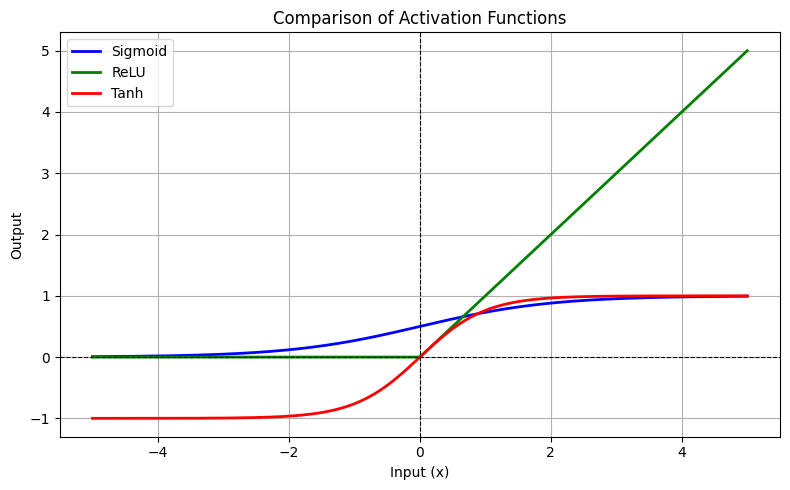

In [71]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 300)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh_fn(z):
    return np.tanh(z)

def relu_fn(z):
    return np.maximum(0, z)

plt.figure(figsize=(8, 5))

plt.plot(x, sigmoid(x),  label='Sigmoid', color='blue',  linewidth=2)
plt.plot(x, relu_fn(x),  label='ReLU',    color='green', linewidth=2)
plt.plot(x, tanh_fn(x),  label='Tanh',    color='red',   linewidth=2)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.title('Comparison of Activation Functions')
plt.xlabel('Input (x)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

## **Conclusion**

- **Forward propagation** is the process by which input data travels through each layer of a neural network and produces a final prediction
- In this project, the Iris dataset was loaded, normalized, and passed through a manually built two-layer neural network
- **ReLU** was applied in the hidden layer to introduce non-linearity, and **Softmax** was applied in the output layer to convert raw values into class probabilities
- The network successfully completed forward propagation and produced predictions for all three Iris species — Setosa, Versicolor, and Virginica
- The low accuracy observed is expected — weights are randomly initialized and no training has been performed. The network is essentially guessing at this stage
- Training through **backpropagation** and weight updates would significantly improve accuracy
- This project makes it clear that forward propagation alone is not enough to make a good model — it is just the first half of the learning process. The second half, backpropagation, is what actually teaches the network to improve
